### Cell 1 Imports and Paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Paths
PROCESSED_DIR = Path("../data/processed")
OUTPUT_DIR = Path("../outputs/figures")
MODEL_DIR = Path("../models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Cell 2 Load Processed Session Data

In [2]:
# Load session features (parquet)
session_df = pd.read_parquet(PROCESSED_DIR / "user_sessions.parquet")
print("Session data shape:", session_df.shape)
session_df.head()

Session data shape: (1761675, 11)


,visitorid,session_id,start_time,end_time,num_views,num_addtocart,num_transactions,unique_items,categories_viewed,duration_min,purchased
0,0,0,2015-09-11 20:49:49.439,2015-09-11 20:55:17.175,3,0,0,3,3,5.462267,0
1,1,0,2015-08-13 17:46:06.444,2015-08-13 17:46:06.444,1,0,0,1,1,0.000000,0
2,2,0,2015-08-07 17:51:44.567,2015-08-07 18:20:57.845,8,0,0,4,2,29.221300,0
3,3,0,2015-08-01 07:10:35.296,2015-08-01 07:10:35.296,1,0,0,1,1,0.000000,0
4,4,0,2015-09-15 21:24:27.167,2015-09-15 21:24:27.167,1,0,0,1,1,0.000000,0


### Cell 3 Feature Selection for Clustering

In [3]:
# Features to use for clustering
feature_cols = ['num_views', 'num_addtocart', 'num_transactions', 
                'unique_items', 'categories_viewed', 'duration_min']

X = session_df[feature_cols].copy()
print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (1761675, 6)


,num_views,num_addtocart,num_transactions,unique_items,categories_viewed,duration_min
0,3,0,0,3,3,5.462267
1,1,0,0,1,1,0.000000
2,8,0,0,4,2,29.221300
3,1,0,0,1,1,0.000000
4,1,0,0,1,1,0.000000


### Cell 4 Scaling

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save scaler for later use
import joblib
joblib.dump(scaler, MODEL_DIR / "scaler.pkl")
print("Scaler saved to", MODEL_DIR / "scaler.pkl")

Scaler saved to ..\models\scaler.pkl


### Cell 5 Elbow and silhouette: Determine Optimal Number of Clusters

Using 50000 samples for elbow/silhouette analysis
K=2: Inertia=248134, Silhouette=0.831
K=3: Inertia=213337, Silhouette=0.755
K=4: Inertia=182310, Silhouette=0.763
K=5: Inertia=244285, Silhouette=0.770
K=6: Inertia=240008, Silhouette=0.764
K=7: Inertia=238160, Silhouette=0.782
K=8: Inertia=187610, Silhouette=0.762
K=9: Inertia=166710, Silhouette=0.805
K=10: Inertia=218561, Silhouette=0.760


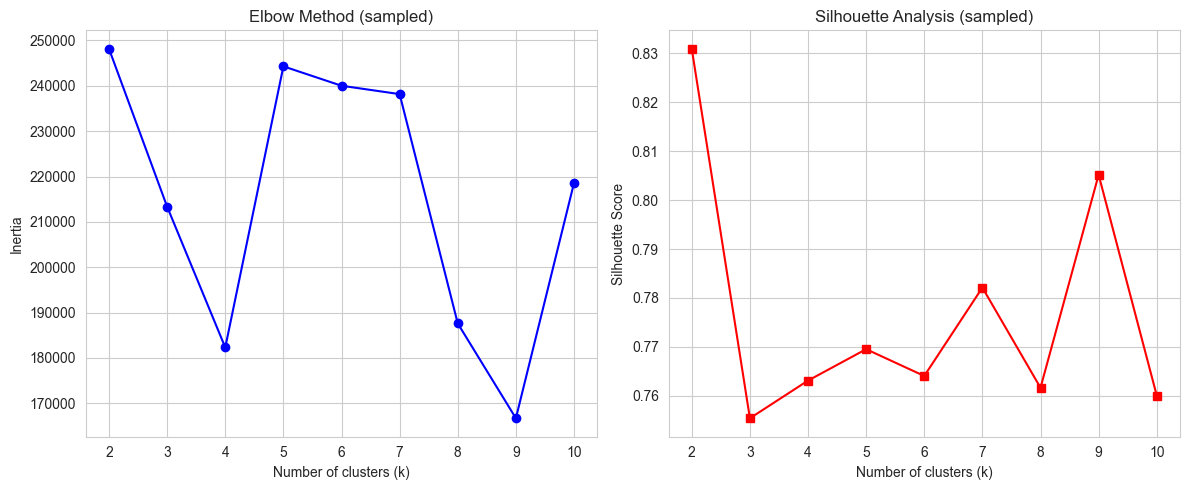

In [6]:
from sklearn.cluster import MiniBatchKMeans

# If data is too large, take a sample for elbow/silhouette
sample_size = min(50000, len(X_scaled))
if len(X_scaled) > sample_size:
    np.random.seed(42)
    indices = np.random.choice(len(X_scaled), sample_size, replace=False)
    X_sample = X_scaled[indices]
else:
    X_sample = X_scaled

print(f"Using {len(X_sample)} samples for elbow/silhouette analysis")

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    # Use MiniBatchKMeans for speed
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000, n_init=10)
    kmeans.fit(X_sample)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_sample, kmeans.labels_)
    silhouette_scores.append(sil)
    print(f"K={k}: Inertia={kmeans.inertia_:.0f}, Silhouette={sil:.3f}")

# Plot elbow and silhouette
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method (sampled)')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'rs-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis (sampled)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "kmeans_elbow_silhouette.png", dpi=150)
plt.show()

### Cell 6 Interpretation: Fit final K‑Means model

In [7]:
optimal_k = 4   # adjust based on the plots
# Use MiniBatchKMeans on full dataset
final_kmeans = MiniBatchKMeans(n_clusters=optimal_k, random_state=42, batch_size=1000, n_init=10)
clusters = final_kmeans.fit_predict(X_scaled)

session_df['cluster'] = clusters

# Save results
session_df[['visitorid', 'session_id', 'cluster']].to_csv(PROCESSED_DIR / "user_clusters.csv", index=False)
joblib.dump(final_kmeans, MODEL_DIR / "kmeans_model.pkl")
print(f"K-Means model (k={optimal_k}) saved to", MODEL_DIR / "kmeans_model.pkl")
print("Cluster labels added to session_df and saved to", PROCESSED_DIR / "user_clusters.csv")

K-Means model (k=4) saved to ..\models\kmeans_model.pkl
Cluster labels added to session_df and saved to ..\data\processed\user_clusters.csv


### Cell 7 Visualise Clusters using PCA

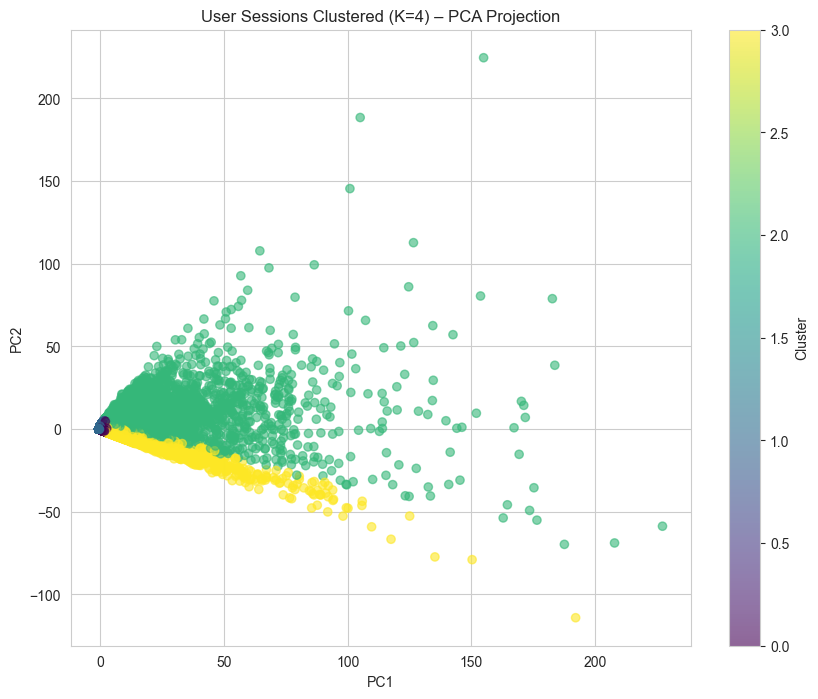

Explained variance ratio: [0.63957754 0.17548196]
Total explained: 0.8150594961815695


In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'User Sessions Clustered (K={optimal_k}) – PCA Projection')
plt.savefig(OUTPUT_DIR / "kmeans_pca_clusters.png", dpi=150)
plt.show()

# Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained:", sum(pca.explained_variance_ratio_))

### Cell 8 Cluster profiles

Purchase rate by cluster:
 cluster
0    0.015533
1    0.001531
2    0.729646
3    0.008056
Name: purchased, dtype: float64


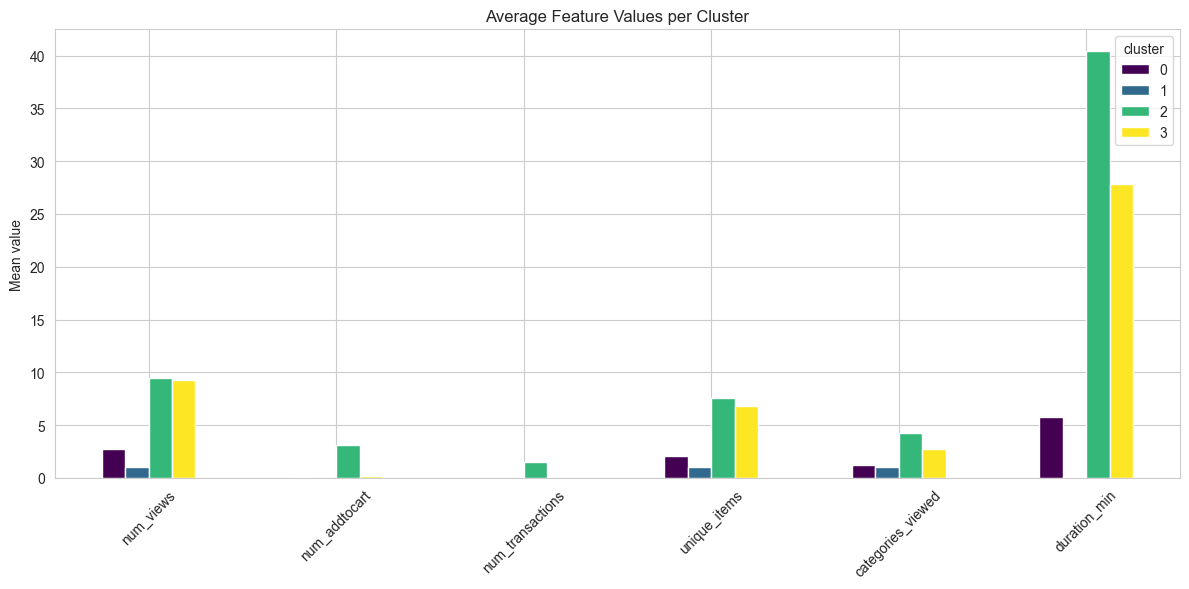

In [9]:
# Mean feature values per cluster (on original scale)
cluster_profiles = session_df.groupby('cluster')[feature_cols].mean()
cluster_profiles

# Also compute purchase rate per cluster
purchase_by_cluster = session_df.groupby('cluster')['purchased'].mean()
print("Purchase rate by cluster:\n", purchase_by_cluster)

# Visualise feature means
cluster_profiles.T.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Average Feature Values per Cluster')
plt.ylabel('Mean value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cluster_profiles.png", dpi=150)
plt.show()

### Cell 9 3D Visualisation (mpl_toolkits)

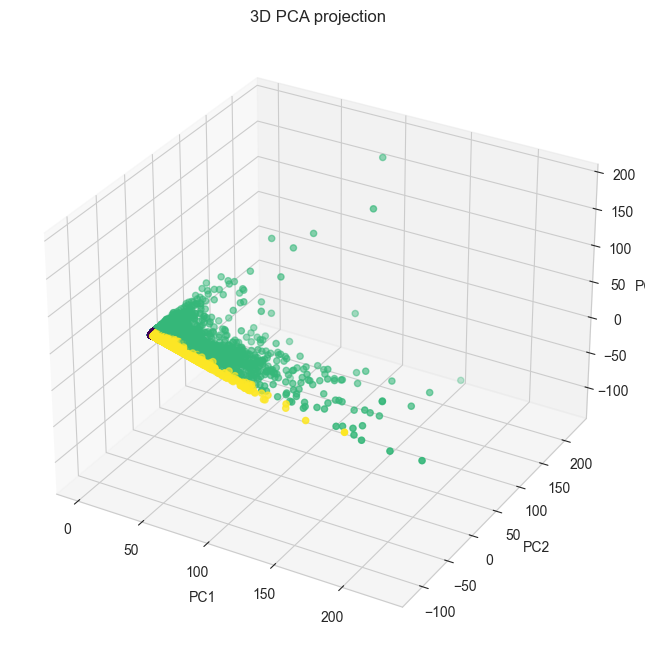

In [10]:
from mpl_toolkits.mplot3d import Axes3D
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=clusters, cmap='viridis')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
plt.title('3D PCA projection')
plt.show()